In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
import xarray as xr
import numpy as np
import os
import warnings

plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['font.size'] = 14

warnings.filterwarnings("ignore")

In [2]:
city = "JP-Yoy"
surf = "../data/URBAN_PLUMBER/input_files/{city}/surfdata_1x1_{city}_detailed_simyr2000_c230710.nc"
surf = xr.open_dataset(surf.format(city=city))
WTLUNIT_ROOF = surf["WTLUNIT_ROOF"].values.flatten()[2]
WTROAD_PERV = surf["WTROAD_PERV"].values.flatten()[2]

In [3]:
ds_list = []
ds_list_jja = []
p_dict = {
    'action_mode': [],
    'tg_threshold': [], 
    'water_tank_size': [],
}
outputpath='../data/water_tank_eval/'
ref_dsf = '/home/junjie/github/UrbSprIrr/data/workdir/outputfolder/lnd/hist/roofsp_raw.clm2.h0.2006-01-01-00000.nc'
ref_ds = xr.open_dataset(ref_dsf).sel(column=1,time = slice('2010', '2019'))
_ref_ds = xr.open_dataset(ref_dsf).sel(time = slice('2010', '2019')) 
ref_ds['QOVER'] = _ref_ds['QOVER'].sel(column=1)*WTLUNIT_ROOF + \
                  _ref_ds['QOVER'].sel(column=4)*(1-WTLUNIT_ROOF)*(1-WTROAD_PERV) + \
                  _ref_ds['QOVER'].sel(column=5)*(1-WTLUNIT_ROOF)*WTROAD_PERV

ref_ds['time'] = ref_ds['time'].dt.round('min') + np.timedelta64(9, 'h')    
#ref_ds_jja = ref_ds.sel(time=ref_ds['time.season']=='JJA')
ref_ds_jja = ref_ds.sel(time=(ref_ds['time.month']>=6) & (ref_ds['time.month']<=9))
for f in os.listdir(outputpath):
    f1 = outputpath + f
    ds = xr.open_dataset(f1).sel(column=1,time = slice('2010', '2019'))    
    _ds = xr.open_dataset(f1).sel(time = slice('2010', '2019')) 
    ds['QOVER'] = _ds['QOVER'].sel(column=1)*WTLUNIT_ROOF + \
                  _ds['QOVER'].sel(column=4)*(1-WTLUNIT_ROOF)*(1-WTROAD_PERV) + \
                  _ds['QOVER'].sel(column=5)*(1-WTLUNIT_ROOF)*WTROAD_PERV

    ds['time'] = ds['time'].dt.round('min') + np.timedelta64(9, 'h')
    exp0 = float(f.split('_')[2])
    exp1 = float(f.split('_')[3])
    exp2 = float(f.split('_')[4].split('.nc')[0])
    
    ds_list.append(ds)
    #6，7，8，9
    ds_list_jja.append(ds.sel(time=(ds['time.month']>=6) & (ds['time.month']<=9)))
    p_dict['action_mode'].append(exp0)
    p_dict['tg_threshold'].append(exp1)
    p_dict['water_tank_size'].append(exp2)
    
rwts_dict = {
    p_dict['water_tank_size'][i]: ds_list[i] for i in range(len(ds_list))
}
rwts_dict_jja = {
    p_dict['water_tank_size'][i]: ds_list_jja[i] for i in range(len(ds_list))
}

In [4]:
def get_plot_data(rwts_dict, ref_ds, X, var, ax):

    y = []
    ref = ref_ds[var].mean('time').values
    rwts = np.array(list(rwts_dict.keys()))
    rwts.sort()
    for w in rwts:
        rain = rwts_dict[w][var].mean('time')
        y.append(rain.values)
    
    y = np.array(y).flatten() - ref
    print(y)
    print(X)
    ax.scatter(x=X, y=y)        
    return X, y

def plot_profile(rwts_dict, ref_ds, var, timetype, ax):
    colors = plt.get_cmap('Blues')(np.linspace(0, 1, len(rwts_dict)+2))
    rwts = np.array(list(rwts_dict.keys()))
    rwts.sort()
    i = 0
    
    if var in ['TG', 'TSA']:
        (ref_ds[var].groupby(f'time.{timetype}').mean('time')-273.15).plot(ax=ax, label='Reference', color='#E02927')
    elif var in ['QOVER']:
        qover = ref_ds[var]*3600
        (qover.groupby(f'time.{timetype}').mean('time')).plot(ax=ax, label='Reference', color='#E02927')
    else:
        ref_ds[var].groupby(f'time.{timetype}').mean('time').plot(ax=ax, label='Reference', color='#E02927')
    for w in rwts:
        if var in ['TG', 'TSA']:
            (rwts_dict[w][var].groupby(f'time.{timetype}').mean('time')-273.15).plot(ax=ax, label='Roof sprinkling', color=colors[i+2])
        elif var in ['QOVER']:
            qover = rwts_dict[w][var]*3600
            (qover.groupby(f'time.{timetype}').mean('time')).plot(ax=ax, label='Roof sprinkling', color=colors[i+2])
        else:
            rwts_dict[w][var].groupby(f'time.{timetype}').mean('time').plot(ax=ax, label='Roof sprinkling', color=colors[i+2])
        i += 1

def plot_pdf(rwts_dict, ref_ds, var, ax):
    colors = plt.get_cmap('Blues')(np.linspace(0, 1, len(rwts_dict)+2))
    rwts = np.array(list(rwts_dict.keys()))
    rwts.sort()
    i = 0
    
    if var in ['TG', 'TSA']:
        #(ref_ds[var]-273.15).plot.kde(ax=ax, label='Reference', color='#E02927')
        sns.kdeplot(ref_ds[var].values-273.15, ax=ax, label='Reference', color='#E02927')
    elif var in ['QOVER']:
        ref_ds[var] = ref_ds[var]*3600
        sns.kdeplot(ref_ds[var].values, ax=ax, label='Reference', color='#E02927')
    else:
        #ref_ds[var].plot.kde(ax=ax, label='Reference', color='#E02927')
        sns.kdeplot(ref_ds[var].values, ax=ax, label='Reference', color='#E02927')
    
    for w in rwts:
        if var in ['TG', 'TSA']:
            #(rwts_dict[w][var]-273.15).plot.kde(ax=ax, label='Roof sprinkling', color=colors[i+2])
            sns.kdeplot(rwts_dict[w][var].values-273.15, ax=ax, label='Roof sprinkling', color=colors[i+2])
        elif var in ['QOVER']:
            qover = rwts_dict[w][var]*3600
            sns.kdeplot(qover.values, ax=ax, label='Roof sprinkling', color=colors[i+2])
        else:
            #rwts_dict[w][var].plot.kde(ax=ax, label='Roof sprinkling', color=colors[i+2])
            sns.kdeplot(rwts_dict[w][var].values, ax=ax, label='Roof sprinkling', color=colors[i+2])
        i += 1
    

## plot diurnal profile

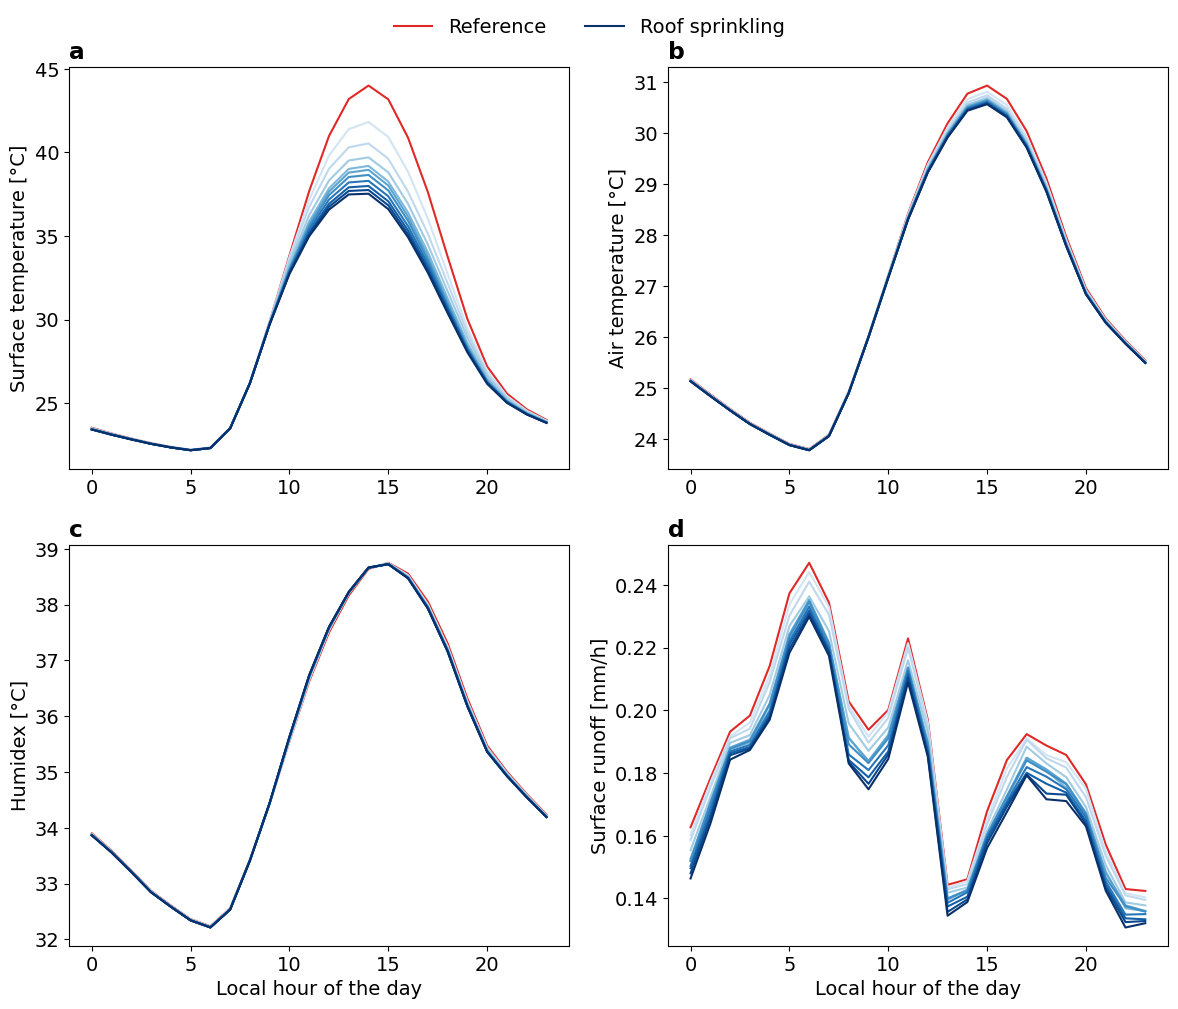

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs = axs.flatten()

vas = ['TG', 'TSA', 'HUMIDEX', 'QOVER']
titles = ['a', 'b', 'c', 'd']
ylabels = ['Surface temperature [°C]', 'Air temperature [°C]', 'Humidex [°C]', 'Surface runoff [mm/h]']
i = 0
for ax in axs:
    plot_profile(rwts_dict_jja, ref_ds_jja, vas[i], 'hour', ax)
    ax.set_title(titles[i], loc='left', fontweight='bold')
    ax.set_ylabel(ylabels[i])
    
    if i in [2, 3]:
        ax.set_xlabel('Local hour of the day')
    else:
        ax.set_xlabel('')
    
    i += 1

handles, labels = axs[0].get_legend_handles_labels()
handles = [handles[0], handles[-1]]
labels = [labels[0], labels[-1]]
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02), frameon=False)
fig.tight_layout()
plt.savefig('../data/figs/diurnal_profile.pdf', bbox_inches='tight', dpi=300)

## plot monthly profile

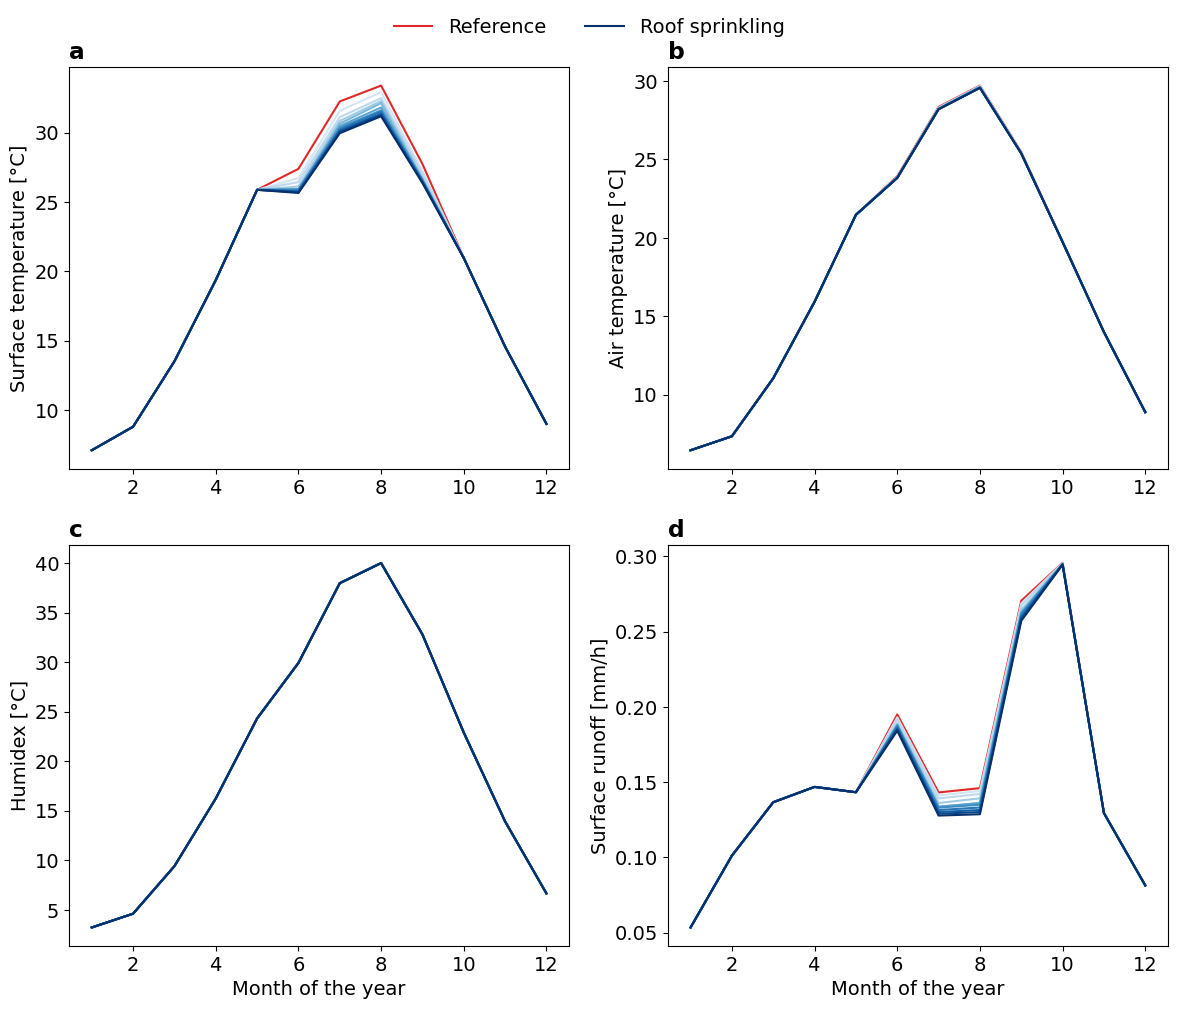

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs = axs.flatten()

vas = ['TG', 'TSA', 'HUMIDEX', 'QOVER']
titles = ['a', 'b', 'c', 'd']
ylabels = ['Surface temperature [°C]', 'Air temperature [°C]', 'Humidex [°C]', 'Surface runoff [mm/h]']
i = 0
for ax in axs:
    plot_profile(rwts_dict, ref_ds, vas[i], 'month', ax)
    ax.set_title(titles[i], loc='left', fontweight='bold')
    ax.set_ylabel(ylabels[i])
    
    if i in [2, 3]:
        ax.set_xlabel('Month of the year')
    else:
        ax.set_xlabel('')
    i += 1

handles, labels = axs[0].get_legend_handles_labels()
handles = [handles[0], handles[-1]]
labels = [labels[0], labels[-1]]
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02), frameon=False)
fig.tight_layout()
plt.savefig('../data/figs/monthly_profile.pdf', bbox_inches='tight', dpi=300)

## Plot PDF

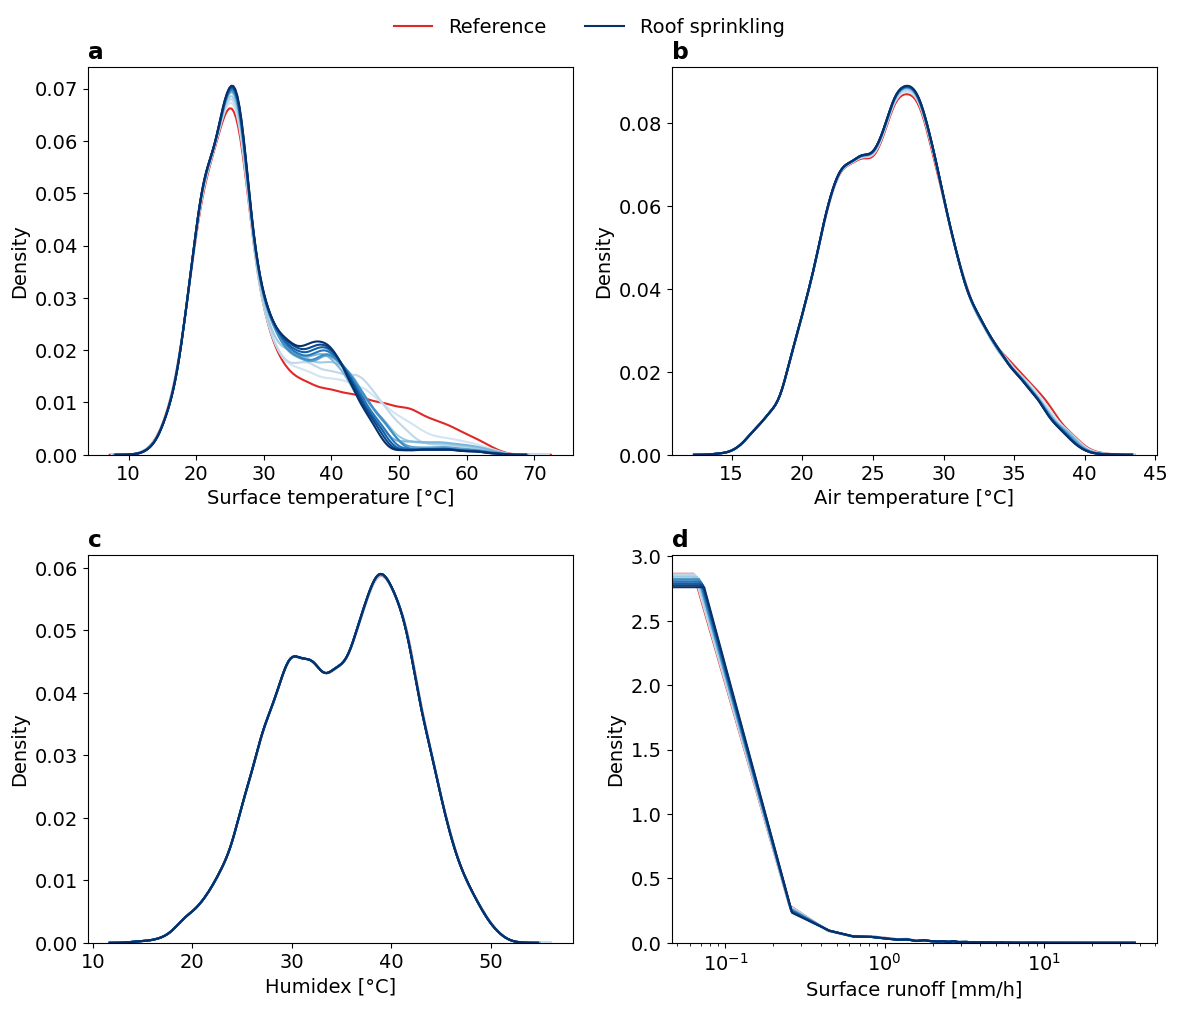

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs = axs.flatten()

vas = ['TG', 'TSA', 'HUMIDEX', 'QOVER']
titles = ['a', 'b', 'c', 'd']
ylabels = ['Surface temperature [°C]', 'Air temperature [°C]', 'Humidex [°C]', 'Surface runoff [mm/h]']
i = 0
for ax in axs:
    plot_pdf(rwts_dict_jja, ref_ds_jja, vas[i], ax)
    ax.set_title(titles[i], loc='left', fontweight='bold')
    ax.set_ylabel('Density')
    ax.set_xlabel(ylabels[i])
    
    #if i == 3:
        #ax.set_xlim(-0., 0.001)
    
    if vas[i] == 'QOVER':
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
        ax.set_xscale('log')

    i += 1

handles, labels = axs[0].get_legend_handles_labels()
handles = [handles[0], handles[-1]]
labels = [labels[0], labels[-1]]
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02), frameon=False)
fig.tight_layout()
plt.savefig('../data/figs/density_profile.pdf', bbox_inches='tight', dpi=300)

In [8]:
def heat_wave_analysis(ds, var, t_threshold = 35+273.15, duration_threshold = 3, duration_break = 1):
    
    data = ds[var].resample(time='1D').max().values
    #plt.plot(data)
    intensity = []
    duration = []
    
    duration_temp=0
    duration_break_temp=0
    intensity_temp = 0
    intensity_break_temp = 0
    
    for t in data:

        if t >= t_threshold:
            duration_temp += 1
            intensity_temp += t
        
        if duration_temp > 0 and t < t_threshold:
            duration_break_temp += 1
            intensity_break_temp += t
            
        if (t >= t_threshold) and (duration_break_temp <= duration_break):

            duration_temp = duration_temp + duration_break_temp + 1
            intensity_temp = intensity_temp + intensity_break_temp + t
            duration_break_temp = 0
            intensity_break_temp = 0
            
        if ((t < t_threshold) and (duration_temp >= duration_threshold)) and (duration_break_temp > duration_break):
            intensity.append(intensity_temp/duration_temp)
            duration.append(duration_temp)
            duration_temp = 0
            intensity_temp = 0
            duration_break_temp = 0
            intensity_break_temp = 0
        
        elif duration_break_temp > duration_break:
            duration_temp = 0
            intensity_temp = 0
            duration_break_temp = 0
            intensity_break_temp = 0
            
    return intensity, duration

In [9]:
def get_heat_wave_data(ds_list, ref_ds, var, t_threshold = 35+273.15, duration_threshold = 3, duration_break = 1):
    
    intensity = []
    duration = []
    total_days = []
    frequency = []
    intensity_temp, duration_temp = heat_wave_analysis(ref_ds, var, t_threshold, duration_threshold, duration_break)
    intensity.append(sum(intensity_temp)/len(intensity_temp))
    duration.append(sum(duration_temp)/len(duration_temp))
    total_days.append(sum(duration_temp))
    frequency.append(len(duration_temp))
    print(intensity, duration, total_days, frequency)
    for ds in ds_list:
        intensity_temp, duration_temp = heat_wave_analysis(ds, var, t_threshold, duration_threshold, duration_break)
        intensity.append(sum(intensity_temp)/len(intensity_temp))
        duration.append(sum(duration_temp)/len(duration_temp))
        total_days.append(sum(duration_temp))
        frequency.append(len(duration_temp))
    return intensity, duration, total_days, frequency

In [10]:
intensity, duration, total_days, frequency = get_heat_wave_data(ds_list, ref_ds, 'TSA', t_threshold = 35+273.15, duration_threshold = 3, duration_break = 1)

[np.float32(309.9483)] [13.693877551020408] [671] [49]


[np.float32(309.9483)] [13.693877551020408] [671] [49]
[np.float32(310.28726)] [9.830508474576272] [580] [59]


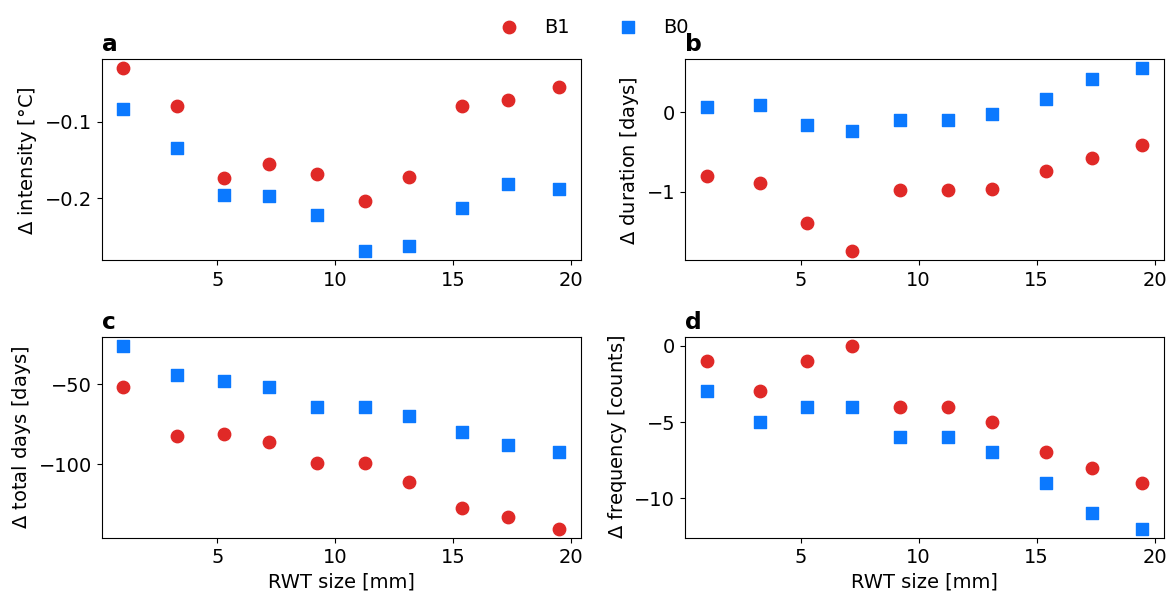

In [11]:
fig = plt.figure(figsize=(12, 6))

axs = fig.subplots(2, 2)

X = p_dict['water_tank_size'].copy()

def plot_heat_wave_analysis(intensity, duration, total_days, frequency, X, label, axs):
    intensity_plot = [i-intensity[0] for i in intensity[1:]]
    duration_plot = [i-duration[0] for i in duration[1:]]
    total_days_plot = [i-total_days[0] for i in total_days[1:]]
    frequency_plot = [i-frequency[0] for i in frequency[1:]]
    axs = axs.flatten()
    colors = {"B1": "#E02927", "B0":"#0B79FF"}
    markers = {"B1": "o", "B0":"s"}
    for ax, y in zip(axs, [intensity_plot, duration_plot, total_days_plot, frequency_plot]):
        ax.scatter(X, y, label=label, color=colors[label], s=80, marker=markers[label])

intensity, duration, total_days, frequency = get_heat_wave_data(ds_list, ref_ds, 'TSA', 
                                                                t_threshold = 35+273.15, 
                                                                duration_threshold = 3, 
                                                                duration_break = 1)
plot_heat_wave_analysis(intensity, duration, total_days, frequency, X, 'B1', axs)

intensity, duration, total_days, frequency = get_heat_wave_data(ds_list, ref_ds, 'TSA', 
                                                                t_threshold = 35+273.15, 
                                                                duration_threshold = 3, 
                                                                duration_break = 0)
plot_heat_wave_analysis(intensity, duration, total_days, frequency, X, 'B0', axs)

handls, labels = fig.gca().get_legend_handles_labels()[0:2]
fig.legend(handls, labels, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))

vars=['$\Delta$ intensity [°C]', '$\Delta$ duration [days]', '$\Delta$ total days [days]', '$\Delta$ frequency [counts]']
titles = ['a', 'b', 'c', 'd']
for i, ax in enumerate(axs.flatten()):
    ax.set_xlabel('Water Tank Size')
    ax.set_ylabel(vars[i])
    ax.set_title(titles[i], loc='left', fontweight='bold')
    
    if i in [2, 3]:
        ax.set_xlabel('RWT size [mm]')
    else:
        ax.set_xlabel('')

fig.tight_layout()
plt.savefig('../data/figs/heat_wave.pdf', bbox_inches='tight', dpi=300)
plt.show()